# Data Profiling
## Análisis Financiero de las 10.000 Empresas Más Grandes de Colombia

### Objetivo

Realizar un perfilamiento de los datos para comprender la estructura del conjunto de datos, evaluar su calidad e identificar posibles problemas antes de iniciar el proceso ETL.

---

### Fuente de datos

Superintendencia de Sociedades

Base de las 10.000 empresas más grandes de Colombia

Corte 2025

---

### Herramientas

- Python
- Pandas
- NumPy
- Matplotlib

In [1]:
# Importación de librerías


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración de visualización

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [3]:
# 1. Carga de datos

# Ruta del archivo

ruta = r"C:\Users\USUARIO\Documents\GitHub\Empresas-Colombianas\data\Bronze\Base_10000_empresas_2026.xlsx"

# Lectura

df = pd.read_excel(ruta)

print("Base cargada correctamente.")

Base cargada correctamente.


In [4]:
df.head()

,RANKING 2025,NIT,RAZON SOCIAL,SUPERVISOR,REGIÓN,DEPARTAMENTO DOMICILIO,CIUDAD DOMICILIO,CIIU,MACROSECTOR,INGRESOS OPERACIONALES 2025*,GANANCIA (PÉRDIDA) 2025,TOTAL ACTIVOS 2025,TOTAL PASIVOS 2025,TOTAL PATRIMONIO 2025,INGRESOS OPERACIONALES 2024*,GANANCIA (PÉRDIDA) 2024,TOTAL ACTIVOS 2024,TOTAL PASIVOS 2024,TOTAL PATRIMONIO 2024,RANKING 2025.1
0,1,899999068,ECOPETROL S.A,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,B0610 - Extracción de petróleo crudo,MINERO,100590667613,9028764859,198110860034,114350599639,83760260395,1.139233e+11,1.493470e+10,2.142410e+11,1.305441e+11,8.369690e+10,1
1,2,830095213,ORGANIZACIÓN TERPEL S.A.,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,G4661 - Comercio al por mayor de combustibles ...,COMERCIO,26395418332,628485892,8112318463,4699968205,3412350258,2.475201e+10,5.307560e+08,7.971212e+09,4.621825e+09,3.349387e+09,2
2,3,900112515,REFINERIA DE CARTAGENA S.A.,SUPERSERVICIOS,CARIBE,BOLÍVAR,CARTAGENA,C1921 - Fabricación de productos de la refinac...,MANUFACTURA,22395204745,-821398601,34946245504,11566291299,23379954205,2.586091e+10,-2.628626e+08,3.950386e+10,1.192736e+10,2.757650e+10,3
3,4,900276962,D1 S A S,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,G4711 - Comercio al por menor en establecimien...,COMERCIO,21606607933,418933423,6939606162,6724638908,214967254,1.943940e+10,3.732099e+08,6.321816e+09,6.104116e+09,2.177000e+08,4
4,5,890904996,EMPRESAS PÚBLICAS DE MEDELLÍN E.S.P.,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,D3513 - Distribución de energía eléctrica,SERVICIOS,20285629973,4875861363,71083399625,36111926922,34971472703,2.057448e+10,4.825909e+09,6.691806e+10,3.445552e+10,3.246254e+10,5


In [5]:
# 2. Dimensiones del conjunto de datos

filas, columnas = df.shape

print(f"Número de registros: {filas}")
print(f"Número de columnas: {columnas}")

Número de registros: 10000
Número de columnas: 20


###Hallazgos

- Contiene 10.000 registros
- Contiene 20 variables

In [6]:
# 3. Información general

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   RANKING 2025                  10000 non-null  int64  
 1   NIT                           10000 non-null  int64  
 2   RAZON SOCIAL                  10000 non-null  str    
 3   SUPERVISOR                    10000 non-null  str    
 4   REGIÓN                        10000 non-null  str    
 5   DEPARTAMENTO DOMICILIO        10000 non-null  str    
 6   CIUDAD DOMICILIO              10000 non-null  str    
 7   CIIU                          10000 non-null  str    
 8   MACROSECTOR                   10000 non-null  str    
 9   INGRESOS OPERACIONALES 2025*  10000 non-null  int64  
 10  GANANCIA (PÉRDIDA) 2025       10000 non-null  int64  
 11  TOTAL ACTIVOS 2025            10000 non-null  int64  
 12  TOTAL PASIVOS 2025            10000 non-null  int64  
 13  TOTAL PATRIMO

###Hallazgos

- Hay registros que no cuentan con información financiera del año 2024
- Las variables de 2024 aparecen como float64 porque contienen valores nulos

In [7]:
# 4. Inspeccionar nombre de columnas

df.columns.tolist()

['RANKING 2025',
 'NIT',
 'RAZON SOCIAL',
 'SUPERVISOR',
 'REGIÓN',
 'DEPARTAMENTO DOMICILIO',
 'CIUDAD DOMICILIO',
 'CIIU',
 'MACROSECTOR',
 'INGRESOS OPERACIONALES 2025*',
 'GANANCIA (PÉRDIDA) 2025',
 'TOTAL ACTIVOS 2025',
 'TOTAL PASIVOS 2025',
 'TOTAL PATRIMONIO 2025',
 'INGRESOS OPERACIONALES 2024*',
 'GANANCIA (PÉRDIDA) 2024',
 'TOTAL ACTIVOS 2024',
 'TOTAL PASIVOS 2024',
 'TOTAL PATRIMONIO 2024',
 'RANKING 2025.1']

### Hallazgos

- Se identificó una columna duplicada (`RANKING 2025.1`).
- Dos columnas presentan un asterisco (`*`) en el nombre.
- Existen caracteres especiales y espacios que serán estandarizados durante el ETL.

In [8]:
# 5. Valores nulos

nulos = df.isnull().sum()

nulos = nulos[nulos > 0]

nulos.sort_values(ascending=False)

TOTAL PASIVOS 2024              55
TOTAL PATRIMONIO 2024           53
TOTAL ACTIVOS 2024              53
INGRESOS OPERACIONALES 2024*     1
GANANCIA (PÉRDIDA) 2024          1
dtype: int64

In [9]:
# 6. Registros duplicados

duplicados = df.duplicated().sum()

print(f"Registros duplicados: {duplicados}")

Registros duplicados: 0


In [10]:
# 7. Estadísticas descriptivas

df.describe().T

,count,mean,std,min,25%,50%,75%,max
RANKING 2025,10000.0,5.000500e+03,2.886896e+03,1.000000e+00,2.500750e+03,5000.5,7.500250e+03,1.000000e+04
NIT,10000.0,8.678463e+08,4.007160e+07,8.000003e+08,8.300512e+08,891224132.0,9.005609e+08,9.019666e+08
INGRESOS OPERACIONALES 2025*,10000.0,1.853802e+08,1.247754e+09,2.125605e+07,3.191299e+07,51954860.0,1.136822e+08,1.005907e+11
GANANCIA (PÉRDIDA) 2025,10000.0,1.386655e+07,1.581161e+08,-1.983319e+09,4.666448e+05,1750991.0,5.360869e+06,9.028765e+09
TOTAL ACTIVOS 2025,10000.0,2.560405e+08,2.596320e+09,3.312980e+05,1.937913e+07,40623242.0,1.066755e+08,1.981109e+11
TOTAL PASIVOS 2025,10000.0,1.376665e+08,1.669713e+09,0.000000e+00,8.557942e+06,19634044.5,5.312068e+07,1.143506e+11
TOTAL PATRIMONIO 2025,10000.0,1.183740e+08,1.136198e+09,-1.431150e+09,6.809172e+06,16656508.5,4.498582e+07,8.376026e+10
INGRESOS OPERACIONALES 2024*,9999.0,1.755748e+08,1.351397e+09,0.000000e+00,2.833543e+07,47176902.0,1.047237e+08,1.139233e+11
GANANCIA (PÉRDIDA) 2024,9999.0,1.256449e+07,2.018530e+08,-1.342691e+09,3.219695e+05,1428454.0,4.488644e+06,1.493470e+10
TOTAL ACTIVOS 2024,9947.0,2.530935e+08,2.749484e+09,0.000000e+00,1.752520e+07,37737614.0,9.967274e+07,2.142410e+11


In [11]:
# 8. Variables categóricas

df.describe(include="object").T

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_18760\1636964281.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
RAZON SOCIAL,10000,9998,NEWREST SERVICES COLOMBIA S.A.S,2
SUPERVISOR,10000,5,SUPERSOCIEDADES,8916
REGIÓN,10000,9,BOGOTÁ-CUNDINAMARCA,4806
DEPARTAMENTO DOMICILIO,10000,37,DISTRITO CAPITAL DE BOGOTÁ,4001
CIUDAD DOMICILIO,10000,432,BOGOTA D.C.,3587
CIIU,10000,375,G4631 - Comercio al por mayor de productos ali...,314
MACROSECTOR,10000,6,COMERCIO,3718


In [12]:
# 9. Valores únicos por columna

df.nunique().sort_values()

SUPERVISOR                          5
MACROSECTOR                         6
REGIÓN                              9
DEPARTAMENTO DOMICILIO             37
CIIU                              375
CIUDAD DOMICILIO                  432
TOTAL PASIVOS 2024               9937
TOTAL PATRIMONIO 2024            9940
TOTAL ACTIVOS 2024               9943
GANANCIA (PÉRDIDA) 2024          9969
GANANCIA (PÉRDIDA) 2025          9983
INGRESOS OPERACIONALES 2024*     9984
TOTAL PATRIMONIO 2025            9997
TOTAL PASIVOS 2025               9998
RAZON SOCIAL                     9998
TOTAL ACTIVOS 2025               9998
INGRESOS OPERACIONALES 2025*     9999
NIT                             10000
RANKING 2025                    10000
RANKING 2025.1                  10000
dtype: int64

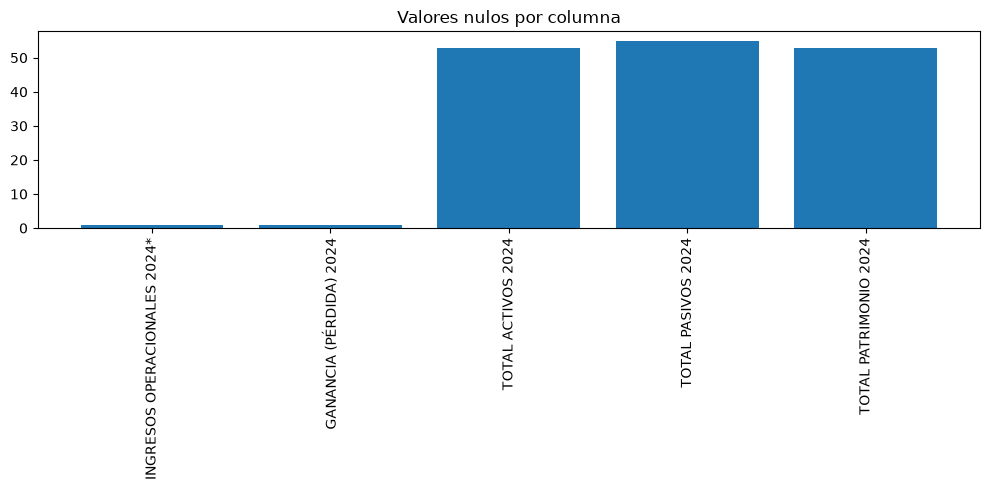

In [13]:
# 10. Distribución de valores nulos

nulos = df.isnull().sum()

nulos = nulos[nulos > 0]

plt.figure(figsize=(10,5))

plt.bar(nulos.index, nulos.values)

plt.xticks(rotation=90)

plt.title("Valores nulos por columna")

plt.tight_layout()

plt.show()

In [14]:
# 11. Variables numéricas

variables_numericas = df.select_dtypes(include=np.number).columns

variables_numericas

Index(['RANKING 2025', 'NIT', 'INGRESOS OPERACIONALES 2025*',
       'GANANCIA (PÉRDIDA) 2025', 'TOTAL ACTIVOS 2025', 'TOTAL PASIVOS 2025',
       'TOTAL PATRIMONIO 2025', 'INGRESOS OPERACIONALES 2024*',
       'GANANCIA (PÉRDIDA) 2024', 'TOTAL ACTIVOS 2024', 'TOTAL PASIVOS 2024',
       'TOTAL PATRIMONIO 2024', 'RANKING 2025.1'],
      dtype='str')

In [15]:
# 12. Variables categóricas

variables_categoricas = df.select_dtypes(exclude=np.number).columns

variables_categoricas

Index(['RAZON SOCIAL', 'SUPERVISOR', 'REGIÓN', 'DEPARTAMENTO DOMICILIO',
       'CIUDAD DOMICILIO', 'CIIU', 'MACROSECTOR'],
      dtype='str')

In [21]:
df['REGIÓN'].unique()

<StringArray>
['BOGOTÁ-CUNDINAMARCA',              'CARIBE',           'ANTIOQUIA',
            'PACÍFICO',    'CENTRO - ORIENTE',        'EJE CAFETERO',
              'CENTRO',   'LLANOS ORIENTALES',            'AMAZONÍA']
Length: 9, dtype: str

In [22]:
df['DEPARTAMENTO DOMICILIO'].unique()

<StringArray>
['DISTRITO CAPITAL DE BOGOTÁ',                    'BOLÍVAR',
                  'ANTIOQUIA',                  'ATLÁNTICO',
            'VALLE DEL CAUCA',                  'MAGDALENA',
               'CUNDINAMARCA',               'SANTANDER CO',
                  'RISARALDA',                     'CALDAS',
      'NORTE DE SANTANDER CO',                      'HUILA',
                     'BOYACÁ',                       'META',
                      'CAUCA',                     'TOLIMA',
                     'NARIÑO',                      'SUCRE',
                    'QUINDÍO',    'DEPARTAMENTO DE CÓRDOBA',
                   'CASANARE',   'SAN ANDRÉS Y PROVIDENCIA',
                    'CAQUETÁ',                     'ARAUCA',
                      'CESAR',                      'CHOCÓ',
                 'LA GUAJIRA',                     'Arauca',
                'AMAZONAS CO',                   'PUTUMAYO',
                   'GUAVIARE',                 'La Guajira',
          

In [26]:
df['CIUDAD DOMICILIO'].unique()

<StringArray>
[                    'BOGOTA D.C.',                       'CARTAGENA',
                        'MEDELLIN',                        'ENVIGADO',
                    'BARRANQUILLA',          'BARRANQUILLA-ATLANTICO',
                    'BOGOTÁ, D.C.',                           'YUMBO',
                    'BOGOTA, D.C.',              'MEDELLIN-ANTIOQUIA',
 ...
      'SABANA-DE-TORRES-SANTANDER',              'TABIO-CUNDINAMARCA',
               'YACUANQUER-NARINO', '25269 - FACATATIVA-CUNDINAMARCA',
           'ANOLAIMA-CUNDINAMARCA',                    'GUAMO-TOLIMA',
           'SIMIJACA-CUNDINAMARCA',         '63001 - ARMENIA-QUINDIO',
                  'BUESACO-NARINO',            'PLANETA-RICA-CORDOBA']
Length: 432, dtype: str

In [27]:
df['MACROSECTOR'].unique()

<StringArray>
[      'MINERO',     'COMERCIO',  'MANUFACTURA',    'SERVICIOS',
 'CONSTRUCCIÓN', 'AGROPECUARIO']
Length: 6, dtype: str

# 13. Conclusiones del perfilamiento

En esta sección se documentarán los principales hallazgos del análisis.

- Número de registros: 10.000 registros
- Número de columnas: 20 columnas
- Variables numéricas: 'RANKING 2025', 'NIT', 'INGRESOS OPERACIONALES 2025*',
       'GANANCIA (PÉRDIDA) 2025', 'TOTAL ACTIVOS 2025', 'TOTAL PASIVOS 2025',
       'TOTAL PATRIMONIO 2025', 'INGRESOS OPERACIONALES 2024*',
       'GANANCIA (PÉRDIDA) 2024', 'TOTAL ACTIVOS 2024', 'TOTAL PASIVOS 2024',
       'TOTAL PATRIMONIO 2024', 'RANKING 2025.1'
- Variables categóricas: 'RAZON SOCIAL', 'SUPERVISOR', 'REGIÓN', 'DEPARTAMENTO DOMICILIO',
       'CIUDAD DOMICILIO', 'CIIU', 'MACROSECTOR'
- Valores nulos encontrados: TOTAL PASIVOS 2024	(55),
TOTAL PATRIMONIO 2024	(53),
TOTAL ACTIVOS 2024	(53),
INGRESOS OPERACIONALES 2024*	(1),
GANANCIA (PÉRDIDA) 2024	(1).


- Duplicados: 0